(1024, 1024)
(1024, 1024)
(1024, 1024)
-0.41362602 0.4368496
-0.50836146 0.34112805
-0.1888101 1.4527918
corr = 0.9567981963548486
residual mean = -0.010338916089688694
residual std = 0.0074708266002663426
residual max = 0.05265240187992104
residual min = -0.09596791780840114


<Figure size 1800x1000 with 0 Axes>

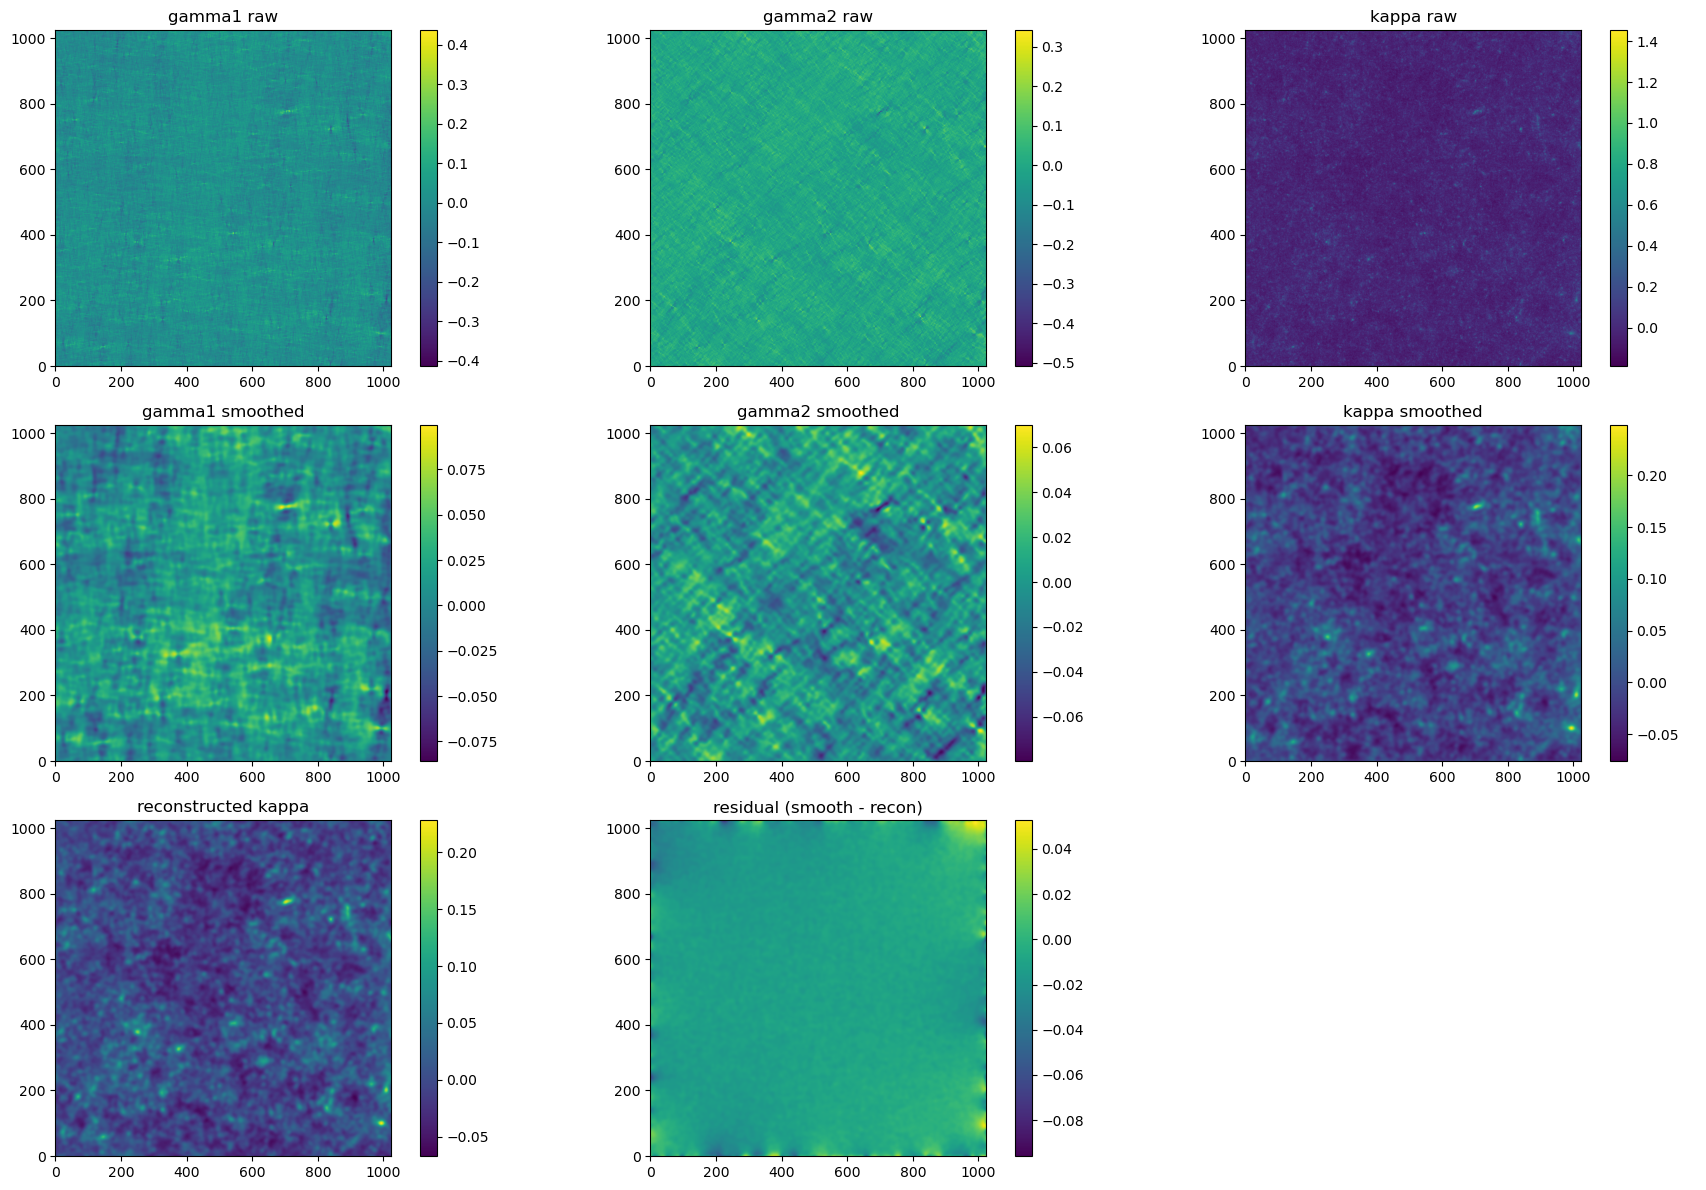

In [3]:
from astropy.io import fits
import numpy as np
import scipy as sci
import matplotlib.pyplot as plt
from astropy.convolution import convolve, Gaussian2DKernel


gamma1 = fits.getdata(
    "/home/tnguser/WL/data/reconstruction/cos0_huhu_Set1_area1_gamma1.fits"
)

gamma2 = fits.getdata(
    "/home/tnguser/WL/data/reconstruction/cos0_huhu_Set1_area1_gamma2.fits"
)

kappa_map = fits.getdata(
    "/home/tnguser/WL/data/reconstruction/cos0_huhu_Set1_area1_kappa.fits"
)

gamma = gamma1 + 1j * gamma2

print(gamma1.shape)
print(gamma2.shape)
print(kappa_map.shape)

print(gamma1.min(), gamma1.max())
print(gamma2.min(), gamma2.max())
print(kappa_map.min(), kappa_map.max())


theta_G_arcmin = 1.5
map_size_deg = 3.5
nx = 1023

theta_pix = (map_size_deg * 60.0) / nx
sigma_pix = (theta_G_arcmin / theta_pix) / np.sqrt(2)

kernel = Gaussian2DKernel(x_stddev=sigma_pix)



gamma1_s = convolve(gamma1, kernel, normalize_kernel=True)
gamma2_s = convolve(gamma2, kernel, normalize_kernel=True)
gamma_s = gamma1_s + 1j * gamma2_s



d = np.zeros((1024,1024), dtype=complex)
di = np.zeros((1024,1024), dtype=complex)

for i in range(1024):
    for j in range(1024):

        l1 = i - 512
        l2 = j - 512

        if l2 != 0 or l1 != 0:

            d[i][j] =  (
                l1*l1 - l2*l2 + 2*1j*l1*l2
            ) / (
                l1*l1 + l2*l2
            )

            di[i][j] =  (
                l1*l1 - l2*l2 - 2*1j*l1*l2
            ) / (
                l1*l1 + l2*l2
            )

        else:
            d[i][j] = 0
            di[i][j] = 0


di_shift = sci.fft.fftshift(di)

gamma_fft = sci.fft.fft2(gamma_s)
gamma_shift = sci.fft.fftshift(gamma_fft)

kappa_e = di * gamma_shift 
kappa_ex = sci.fft.fftshift(kappa_e)

ifft = sci.fft.ifft2(kappa_ex)
ifft_real = np.real(ifft)



kappa_map_s = convolve(kappa_map, kernel, normalize_kernel=True)



ppp_real = kappa_map_s - ifft_real


corr = np.corrcoef(
    kappa_map_s.flatten(),
    ifft_real.flatten()
)[0,1]

print("corr =", corr)
print("residual mean =", np.mean(ppp_real))
print("residual std =", np.std(ppp_real))
print("residual max =", np.max(ppp_real))
print("residual min =", np.min(ppp_real))



vmin = min(np.min(kappa_map_s), np.min(ifft_real))
vmax = max(np.max(kappa_map_s), np.max(ifft_real))

plt.figure(figsize=(18,10))


plt.figure(figsize=(18, 12))

plt.subplot(3, 3, 1)
plt.imshow(gamma1, origin='lower')
plt.title("gamma1 raw")
plt.colorbar()

plt.subplot(3, 3, 2)
plt.imshow(gamma2, origin='lower')
plt.title("gamma2 raw")
plt.colorbar()

plt.subplot(3, 3, 3)
plt.imshow(kappa_map, origin='lower')
plt.title("kappa raw")
plt.colorbar()


plt.subplot(3, 3, 4)
plt.imshow(gamma1_s, origin='lower')
plt.title("gamma1 smoothed")
plt.colorbar()

plt.subplot(3, 3, 5)
plt.imshow(gamma2_s, origin='lower')
plt.title("gamma2 smoothed")
plt.colorbar()

plt.subplot(3, 3, 6)
plt.imshow(kappa_map_s, origin='lower')
plt.title("kappa smoothed")
plt.colorbar()


plt.subplot(3, 3, 7)
plt.imshow(ifft_real, origin='lower')
plt.title("reconstructed kappa")
plt.colorbar()

plt.subplot(3, 3, 8)
plt.imshow(ppp_real, origin='lower')
plt.title("residual (smooth - recon)")
plt.colorbar()

plt.subplot(3, 3, 9)
plt.axis("off")

plt.tight_layout()
plt.show()